<a href="https://colab.research.google.com/github/elenasabbioni/SMARTbiomed_summerschool_2026/blob/main/rare_variant_SAIGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astheeggeggs/testing_colab/blob/main/rare_variant_SAIGE.ipynb)
# 🧬 Gene-Based Association Testing with SAIGE-Gene

SAIGE-Gene is an extension of the SAIGE software specifically designed for performing rare variant association tests. It is particularly powerful because it scales to massive cohorts (like the UK Biobank) while effectively controlling for sample relatedness, population stratification, and highly unbalanced case-control ratios.

In this practical, we will walk through the two core steps of a SAIGE-Gene analysis using a toy dataset, and then visualize pre-computed real-world results.

---

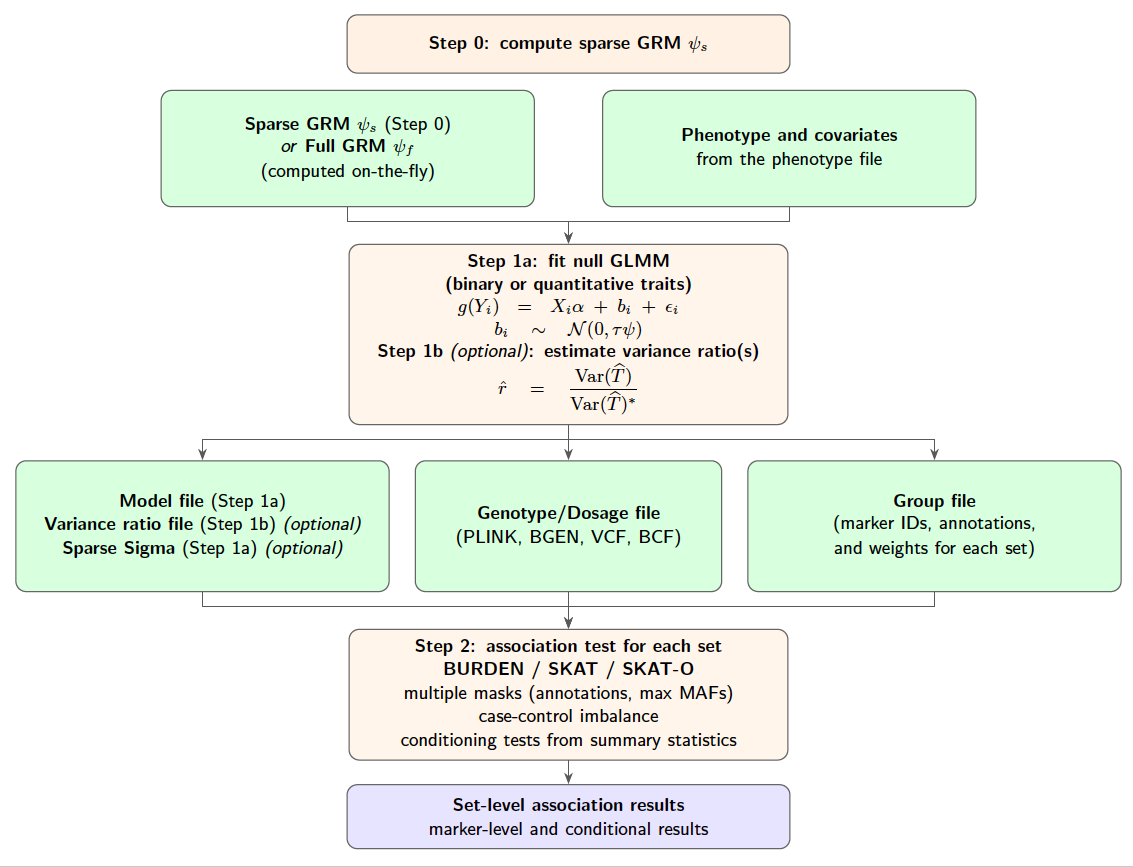

## 🛠️ Environment Initialization and SAIGE Installation
Before diving into genetics, we need to initialize our notebook's multi-language compiler extensions and build our local environment.

To do this, we'll install the SAIGE software directly from its source code using a fast package manager called `pixi`.

Run the setup blocks below to prepare your environment. *(This may (will) take a minute!)*

In [1]:
# Load the R magic extension so we can write native R inside this notebook
%load_ext rpy2.ipython

In [2]:
# Clone the source code repository for SAIGE-gene
!git clone --depth 1 -b main https://github.com/saigegit/SAIGE /content/SAIGE

Cloning into '/content/SAIGE'...
remote: Enumerating objects: 437, done.
remote: Counting objects: 100% (437/437), done.
remote: Compressing objects: 100% (355/355), done.
remote: Total 437 (delta 75), reused 359 (delta 58), pack-reused 0 (from 0)
Receiving objects: 100% (437/437), 49.56 MiB | 11.19 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Updating files: 100% (481/481), done.


In [3]:
# 1. Install the Pixi package manager
!curl -fsSL https://pixi.sh/install.sh | bash

# 2. Inject Pixi dynamically into our active shell environment paths
import os
os.environ['PATH'] = f"{os.environ['HOME']}/.pixi/bin:{os.environ['PATH']}"

# 3. Change directory to the source workspace and build project environments
%cd /content/SAIGE
!pixi install
!rm -rf ~/.cache

# 4. Install the lintools dependency into the SAME isolated library that the
#    SAIGE build (next install cell) targets via R_LIBS_USER. Without this it
#    lands in R's default personal library, which that override does not search,
#    and the build fails with "dependency 'lintools' is not available".
!env -u R_HOME -u R_LIBS -u R_LIBS_SITE \
     R_LIBS_USER=/content/SAIGE/.pixi/envs/default/lib/R/library \
     pixi run Rscript -e 'install.packages("lintools", repos="https://cloud.r-project.org")'

This script will automatically download and install Pixi (latest) for you.
Getting it from this url: https://github.com/prefix-dev/pixi/releases/latest/download/pixi-x86_64-unknown-linux-musl.tar.gz
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 31.8M  100 31.8M    0     0  38.4M      0 --:--:-- --:--:-- --:--:-- 38.4M
The 'pixi' binary is installed into '/root/.pixi/bin'
Updating '/root/.bashrc'
Please restart or source your shell.
/content/SAIGE
⠁ solving              [────────────────────]  0/1                              
⠁ solving              [────────────────────]  0/1  queued: default@linux-64 (li
⠁ solving              [────────────────────]  0/1  queued: default@linux-64 (li
⠁ solving              [────────

In [4]:
%cd /content/SAIGE

# 1. Fetch the exact source release version of PLINK2 required by SAIGE
!curl -L https://github.com/chrchang/plink-ng/archive/refs/tags/v2.0.0-a.6.16.tar.gz | tar -zx
!rm -rf plink-ng
!mv plink-ng-2.0.0-a.6.16 plink-ng

# 2. Compile the PLINK2 library native source archives using the Pixi environment compilers
!pixi run x86_64-conda-linux-gnu-cc -std=c++14 -fPIC -O3 -I.pixi/envs/default/include -L.pixi/envs/default/lib -o libplink2_includes.a plink-ng/2.0/include/*.cc -shared -lz -lzstd -lpthread -lm -ldeflate
!mv libplink2_includes.a .pixi/envs/default/lib

/content/SAIGE
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 4607k    0 4607k    0     0  3246k      0 --:--:--  0:00:01 --:--:-- 8619k


In [5]:
# Build & install the SAIGE R package against the isolated pixi/conda R.
#
# IMPORTANT: pass the R_* overrides ONLY to this subprocess (via `env`) instead
# of mutating the kernel's os.environ. The notebook's own %%R cells use Colab's
# *system* R through rpy2; if R_LIBS_USER is left pointing at the conda R
# library, that system R loads ABI-incompatible conda packages and the graphics
# device breaks -> "failed to load cairo DLL" and
# `dev.off() : cannot shut down device 1 (the null device)` on every %%R cell.
#
# lintools was already installed into this same R_LIBS_USER in the setup cell.
%cd /content/SAIGE
!env -u R_HOME -u R_LIBS -u R_LIBS_SITE \
     R_LIBS_USER=/content/SAIGE/.pixi/envs/default/lib/R/library \
     pixi run R CMD INSTALL .

/content/SAIGE
* installing to library ‘/content/SAIGE/.pixi/envs/default/lib/R/library’
* installing *source* package ‘SAIGE’ ...
** this is package ‘SAIGE’ version ‘1.5.1’
** using staged installation
** libs
using C++ compiler: ‘x86_64-conda-linux-gnu-c++ (conda-forge gcc 15.2.0-19) 15.2.0’
using C++14
x86_64-conda-linux-gnu-c++ -std=gnu++14 -I"/content/SAIGE/.pixi/envs/default/lib/R/include" -DNDEBUG -D SQLITE_ENABLE_COLUMN_METADATA -fpic -w -pedantic -DARMA_64BIT_WORD=1 -D__STDC_FORMAT_MACROS -I../.pixi/envs/default/include -I../plink-ng/2.0/include -I'/content/SAIGE/.pixi/envs/default/lib/R/library/Rcpp/include' -I'/content/SAIGE/.pixi/envs/default/lib/R/library/RcppArmadillo/include' -I'/content/SAIGE/.pixi/envs/default/lib/R/library/RcppParallel/include' -I'/content/SAIGE/.pixi/envs/default/lib/R/library/data.table/include' -I'/content/SAIGE/.pixi/envs/default/lib/R/library/SPAtest/include' -I'/content/SAIGE/.pixi/envs/default/lib/R/library/RcppEigen/include' -I'/content/SAIGE/

In [7]:
%%bash
# Define `saige-Rscript`: a one-line wrapper used by every SAIGE step below.
# It runs Rscript through the isolated pixi/conda R with a clean environment.
# Colab's kernel exports R_HOME / R_LIBS / R_LIBS_SITE pointing at the *system*
# R; if the conda R inherits those it loads the system-built (ABI-incompatible)
# data.table and SAIGE dies with `undefined symbol: R_duplicateAsResizable`.
# We can't clear them globally because the %%R cells DO use the system R via
# rpy2 -- so we scope the override here, in one place.
cat > /usr/local/bin/saige-Rscript <<'EOF'
#!/usr/bin/env bash
exec env -u R_HOME -u R_LIBS -u R_LIBS_SITE \
  R_LIBS_USER=/content/SAIGE/.pixi/envs/default/lib/R/library \
  pixi run Rscript "$@"
EOF
chmod +x /usr/local/bin/saige-Rscript

> ⚠️ **CRITICAL CHECKPOINT:** The installation code cell directly above must conclude with a message reading `* DONE (SAIGE)`. If it doesn't, shout - you won't be the only one, and we'll help you diagnose what went wrong. If it does....read on!

Before testing any specific genes, SAIGE requires us to fit a **Null Generalized Linear Mixed Model (GLMM)**.

This step calculates the baseline variance of our phenotype *without* considering the genetic markers we want to test. It accounts for covariates (like Age, Sex, and Principal Components) and uses a **Genetic Relationship Matrix (GRM)** to adjust for any underlying relatedness or population structure among our samples.

First, we'll need to create a sparse GRM. This takes a randomly sampled set of relatively common markers that have been LD-pruned, and calculates the relatedness between all individuals. The 'sparse' matrix implies that unless individuals are more related than a certain cutoff (which we can specify), their relatedness is forced to 0. This gives a massive speedup when running on biobank scale data!

---

# 🟢 Step 0: Constructing a Sparse Genetic Relationship Matrix (GRM)

This step calculates the genetic background relationships across samples. It is required for running region- and gene-based score tests within SAIGE-Gene.

> 💡 **Key Concept:** A sparse GRM only needs to be computed **once** for a target cohort (e.g., a biobank population) and can be saved and reused across different phenotypes, provided the overall sample list doesn't change.

In [8]:
%cd /content/SAIGE
!saige-Rscript extdata/createSparseGRM.R --help

/content/SAIGE
Warning messages:
1: replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘SAIGE’ 
2: replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘SAIGE’ 
3: replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘SAIGE’ 
Loading required package: optparse
Warning message:
package ‘optparse’ was built under R version 4.5.3 
R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /content/SAIGE/.pixi/envs/default/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone

### Reviewing the Command Options
Take a while to look over these construction flags before running the next cell:

* `--plinkFile`: Points to the genotype files prefix (`.bed`, `.bim`, `.fam`).
* `--nThreads`: Determines processing cores (set to 4 here).
* `--relatednessCutoff`: Genetic threshold below which relationships are set to 0, ensuring the matrix stays computationally light and "sparse."

**Expected Input Files Found Under `./extdata/input/`:**
* `nfam_100_nindep_0_step1_includeMoreRareVariants_poly.bed`
* `nfam_100_nindep_0_step1_includeMoreRareVariants_poly.bim`
* `nfam_100_nindep_0_step1_includeMoreRareVariants_poly.fam`

**Generated Outputs Stored Under `./extdata/output/`:**
* `sparseGRM_relatednessCutoff_0.125_1000_randomMarkersUsed.sparseGRM.mtx` (The core matrix file; can be inspected in R using `Matrix::readMM()`).
* `sparseGRM_relatednessCutoff_0.125_1000_randomMarkersUsed.sparseGRM.mtx.sampleIDs.txt` (The ordered string list of sample IDs matching rows/columns).

These filenames are a bit of a mouthful, but provide super useful information about how they were constructed.

In [9]:
!saige-Rscript extdata/createSparseGRM.R \
  --plinkFile=extdata/input/nfam_100_nindep_0_step1_includeMoreRareVariants_poly \
  --nThreads=4 \
  --outputPrefix=extdata/output/sparseGRM \
  --numRandomMarkerforSparseKin=1000 \
  --relatednessCutoff=0.125

Output streaming troncato alle ultime 5000 righe.
  [11,] .         .         .         .         .         .         .        
  [12,] .         .         .         .         .         .         .        
  [13,] .         .         .         .         .         .         .        
  [14,] .         .         .         .         .         .         .        
  [15,] .         .         .         .         .         .         .        
  [16,] .         .         .         .         .         .         .        
  [17,] .         .         .         .         .         .         .        
  [18,] .         .         .         .         .         .         .        
  [19,] .         .         .         .         .         .         .        
  [20,] .         .         .         .         .         .         .        
  [21,] .         .         .         .         .         .         .        
  [22,] .         .         .         .         .         .         .        
  [23,] .     

The screen output ends with the following text if the job above has been run successfully:

```
[999,] .         .         .         .         ......
[1000,] .         .         .         .         ......

 .....suppressing 968 columns in show(); maybe adjust options(max.print=, width=)
 ..............................
```

If you see this, **move to the next step!**

---

# 🔵 Step 1: Fitting the Null Logistic/Linear Mixed Model

Now that you've got a sparse GRM, we can fit a null generalised linear mixed model (GLMM) accounting for baseline covariates (e.g., age, biological sex, and genetic principal components [PCs]), and population structure via the sparse GRM. This defines our baseline variation under the **null hypothesis of no genetic association**.

Depending on the trait type of the phenotype, $y$ say, SAIGE applies either a linear model (for continuous $y$) or a logistic model (for binary $y$). In the case of binary $y$, we might have:

$$\text{logit}(\pi) = X\alpha + b + ɛ$$

* $\pi$: The probability that an individual displays the binary outcome (that is, $y = 1$).
* $X\alpha$: The fixed effects covariate matrix (e.g., Age, Sex, PCs).
* $b$: The random effect vector modeling background relatedness, distributed as $b \sim N(0, \tau \psi)$ where $\psi$ is your constructed GRM (i.e. it's a correlated noise term).

Let's run a script to perform step 1 of SAIGE, and inspect what's going on under the hood.

In [10]:
!saige-Rscript extdata/step1_fitNULLGLMM.R \
  --sparseGRMFile=extdata/output/sparseGRM_relatednessCutoff_0.125_1000_randomMarkersUsed.sparseGRM.mtx \
  --sparseGRMSampleIDFile=extdata/output/sparseGRM_relatednessCutoff_0.125_1000_randomMarkersUsed.sparseGRM.mtx.sampleIDs.txt \
  --useSparseGRMtoFitNULL=TRUE \
  --plinkFile=extdata/input/nfam_100_nindep_0_step1_includeMoreRareVariants_poly_22chr.forCate_vr \
  --phenoFile=extdata/input/pheno_1000samples.txt_withdosages_withBothTraitTypes.txt \
  --isCateVarianceRatio=TRUE \
  --phenoCol=y_binary \
  --covarColList=x1,x2 \
  --qCovarColList=x2 \
  --sampleIDColinphenoFile=IID \
  --traitType=binary \
  --nThreads=1 \
  --outputPrefix=extdata/output/example_binary_sparseGRM \
  --IsOverwriteVarianceRatioFile=TRUE &> step1_fitNULLGLMM.log

As a reminder, you can see all of the options for SAIGE step 1 in gory detail
by running...

In [11]:
!saige-Rscript extdata/step1_fitNULLGLMM.R --help

Warning messages:
1: replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘SAIGE’ 
2: replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘SAIGE’ 
3: replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘SAIGE’ 
Loading required package: optparse
Warning message:
package ‘optparse’ was built under R version 4.5.3 
R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /content/SAIGE/.pixi/envs/default/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcod

Take a look in the log file that was just output by this script: `step1_fitNULLGLMM.log`.

<details>
  <summary>💡 Click here to reveal!</summary>

  ```
  !cat step1_fitNULLGLMM.log
  ```
</details>

In [13]:
# Don't forget to prepend with `!` if you want to call bash on each line, or
# begin the cell with %%bash.
%%bash
cat step1_fitNULLGLMM.log

Warning messages:
1: replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘SAIGE’ 
2: replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘SAIGE’ 
3: replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘SAIGE’ 
Loading required package: optparse
Warning message:
package ‘optparse’ was built under R version 4.5.3 
R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /content/SAIGE/.pixi/envs/default/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcod

Does the log file end with...
```varRatio_null_noXadj 0.9413749
         V1          V2 V3
1 0.9485805        null  1
2 0.9451629 null_noXadj  1
3 0.9441699        null  2
4 0.9413749 null_noXadj  2
closed the plinkFile!
```

If you see this, **move to the next step**!

---

# 🟣 Step 2: Executing Gene-Based & Set-Based Association Tests

With our null model established, we can read a target marker file containing genotypes or dosages (supporting `VCF`, `BCF`, `BGEN`, or `SAV` - we'll use `BGEN` today) alongside a **group specification file** to run aggregated gene-level calculations like SKAT, Burden, and SKAT-O tests. Here's all the input files we need for step 2:

## Input files
####Dosage/genotype file containing dosages or genotypes of markers to test
`extdata/input/genotype_100markers.bgen`
`extdata/input/genotype_100markers.bgen.bgi`

The `.bgi` file is an index - it allows huge speedups if we want to zip to different parts of the bgen or slice and dice the data.

####Sample file

This file contains one column for sample IDs corresponding to the sample order in the dosage file. No header is included. The file is ONLY for `BGEN` input.

`extdata/input/samplelist.txt`

####Model file from step 1
`extdata/output/example_binary_sparseGRM.rda`

####Variance ratio file from step 1

`extdata/output/example_binary_sparseGRM.varianceRatio.txt`

#### Group File (specific to SAIGE-gene)

`extdata/input/group_new_chrposa1a2.txt`

### Understanding the Group File Format
A group mapping file structures variants into specific genomic sets (e.g., matching a gene identifier). It contains at least two lines for each gene/set. The first two lines are required:
1.  **`var` line:** The gene name followed by structural variant identifiers.
2.  **`anno` line:** The functional annotations matching each variant sequence item.
Optionally, you can include a third line representing the 'weights' for each marker:
3.  **`weight` line** *(optional)***:** Explicit weights per marker. If missing, SAIGE dynamically weights variants via a Beta distribution profile based on Minor Allele Frequency: $\text{Beta}(\text{MAF}, 1, 25)$.

Take a look in the group file that we're going to use for this practical:
Try writing the R code to read and print this file (`extdata/input/group_new_chrposa1a2.txt`) in the empty cell below!

<details>
  <summary>💡 Stuck? Click here to reveal the code solution!</summary>

  ```R
  %%R
  groupfile <- readLines("extdata/input/group_new_chrposa1a2.txt")
  print(groupfile)
  ```
</details>

In [20]:
%%R
# Type your R code in here to take a look at the data
library(data.table)
groupfile <- readLines("extdata/input/group_new_chrposa1a2.txt")
print(groupfile)

[1] "GENE1 var 1:1:A:C 1:2:A:C 1:3:A:C 1:4:A:C 1:5:A:C 1:6:A:C 1:7:A:C 1:8:A:C 1:9:A:C 1:10:A:C 1:11:A:C 1:12:A:C 1:13:A:C 1:14:A:C 1:15:A:C 1:16:A:C 1:17:A:C 1:18:A:C 1:19:A:C 1:20:A:C 1:21:A:C 1:22:A:C 1:23:A:C 1:24:A:C 1:25:A:C 1:26:A:C 1:27:A:C 1:28:A:C 1:29:A:C 1:30:A:C 1:31:A:C 1:32:A:C 1:33:A:C 1:34:A:C 1:35:A:C 1:36:A:C 1:37:A:C 1:38:A:C 1:39:A:C 1:40:A:C 1:41:A:C 1:42:A:C 1:43:A:C 1:44:A:C 1:45:A:C 1:46:A:C 1:47:A:C 1:48:A:C 1:49:A:C 1:50:A:C"          
[2] "GENE1 anno lof lof lof lof lof lof lof lof lof lof missense missense missense missense missense missense missense missense missense missense missense missense missense missense missense missense missense missense missense missense lof lof lof lof lof lof lof lof lof lof lof lof lof lof lof lof lof lof lof lof"                                                                                                                                                      
[3] "GENE3 var 1:51:A:C"                                          

Does the output make sense?

Can you go into R (or python if you're so inclined) and plot what this default $\text{Beta}(\text{MAF}, 1, 25)$ distribution looks like?

<details>
  <summary>💡 Stuck? Click here to reveal an example of a solution!</summary>

```R
%%R
library(ggplot2)

set.seed(42)
df <- data.frame(MAF = rbeta(10000, 1, 25))

ggplot(df, aes(x = MAF)) +
  geom_histogram(bins = 50, fill = "skyblue", color = "black", alpha = 0.7,
                 boundary = 0) +
  theme_bw() +
  labs(title = "Beta(1, 25) Distribution",
       x = "Minor Allele Frequency (MAF)",
       y = "Count")
```

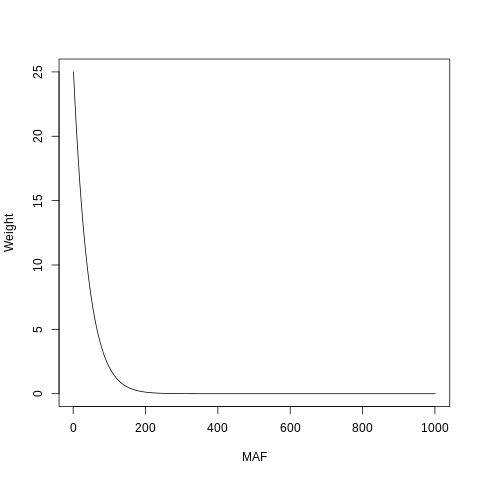

In [25]:
# If you're using R, don't forget to start the cell with %%R
%%R
plot(dbeta(seq(0, 1, 0.001), 1, 25), type = "l", xlab = "MAF", ylab = "Weight")

Does this make sense? Why?

Now let's run Step 2 of SAIGE-gene. Don't worry about all of the flags and inputs, we'll take a look in the `--help` soon!

In [26]:
!saige-Rscript extdata/step2_SPAtests.R \
    --bgenFile=extdata/input/genotype_100markers.bgen \
    --bgenFileIndex=extdata/input/genotype_100markers.bgen.bgi \
    --SAIGEOutputFile=extdata/output/genotype_100markers_bgen_groupTest_out.txt \
    --chrom=1 \
    --AlleleOrder=ref-first \
    --minMAF=0 \
    --minMAC=0.5 \
    --sampleFile=extdata/input/samplelist.txt \
    --GMMATmodelFile=extdata/output/example_binary_sparseGRM.rda \
    --varianceRatioFile=extdata/output/example_binary_sparseGRM.varianceRatio.txt \
    --groupFile=extdata/input/group_new_chrposa1a2.txt \
    --annotation_in_groupTest="lof,missense:lof,missense:lof:synonymous" \
    --maxMAF_in_groupTest=0.0001,0.001,0.01 \
    --is_output_markerList_in_groupTest=TRUE \
    --LOCO=FALSE \
    --is_fastTest=TRUE

Warning messages:
1: replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘SAIGE’ 
2: replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘SAIGE’ 
3: replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘SAIGE’ 
Loading required package: RhpcBLASctl
Warning message:
package ‘optparse’ was built under R version 4.5.3 
R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /content/SAIGE/.pixi/envs/default/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tz

The screen output ends with the following text if the job above has been run successfully:
```
[1] "Analysis done! The set-based tests results have been saved to 'extdata/output/genotype_100markers_bgen_groupTest_out.txt'. The marker lists have been saved to 'extdata/output/genotype_100markers_bgen_groupTest_out.txt.markerList.txt'. The single-variant association tests results have been saved to 'extdata/output/genotype_100markers_bgen_groupTest_out.txt.singleAssoc.txt'."
Warning message:
In SAIGE.getRegionList_new(marker_group_line, nline_per_gene, annolist,  :
  No markers are found for at least one annotation, so region GENE3 is skipped
```
**Congratulations, you've run SAIGE-gene from start to finish!**

Try running the help flag for step 2 and have a read about what each of the flags are doing.

In [27]:
!saige-Rscript extdata/step2_SPAtests.R --help

Warning messages:
1: replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘SAIGE’ 
2: replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘SAIGE’ 
3: replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘SAIGE’ 
Loading required package: RhpcBLASctl
Warning message:
package ‘optparse’ was built under R version 4.5.3 
R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /content/SAIGE/.pixi/envs/default/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tz

Take a look in the output file for the gene-based tests.

What are each of the entries showing?
Try loading and printing this file (`extdata/output/genotype_100markers_bgen_groupTest_out.txt`) using `data.table` in the empty cell below!

<details>
  <summary>💡 Stuck? Click here to reveal the code solution!</summary>

  ```R
  %%R
  library(data.table)

  dt <- fread("extdata/output/genotype_100markers_bgen_groupTest_out.txt")
  print(dt)
  ```
</details>

In [29]:
%%R
library(data.table)

# Read in the output file and think about what each entry is displaying.
dt <- fread("extdata/output/genotype_100markers_bgen_groupTest_out.txt")
head(dt)

   Region                   Group max_MAF     Pvalue Pvalue_Burden Pvalue_SKAT
   <char>                  <char>   <num>      <num>         <num>       <num>
1:  GENE1                     lof   0.001 0.02786874    0.02786874  0.02786874
2:  GENE1                     lof   0.010 0.45953208    0.31055309  0.84300550
3:  GENE1            missense;lof   0.001 0.06199666    0.06199666  0.06199666
4:  GENE1            missense;lof   0.010 0.54387579    0.37102299  0.93856487
5:  GENE1 missense;lof;synonymous   0.001 0.06199666    0.06199666  0.06199666
6:  GENE1 missense;lof;synonymous   0.010 0.54387579    0.37102299  0.93856487
   BETA_Burden  SE_Burden   MAC MAC_case MAC_control Number_rare
         <num>      <num> <int>    <int>       <int>       <int>
1:  0.14671671 0.06671582     5        2           3           0
2: -0.02076271 0.02047479    98        7          91           3
3:  0.09020077 0.04833082    10        3           7           0
4: -0.01606129 0.01795442   119       10   

---

# 📈 Part 2: Working with Real-World Biobank Datasets

When dealing with massive human population biobanks, processing complete genomes requires substantial computing clusters. To save time during our live workshop, we have provided an example dataset containing the finished gene-level analysis results of Atrial Fibrillation (AFib) from a EUR-like genetic ancestry subgroup within the UK Biobank ($N = 28,671$ cases; $373,704$ controls).

First, we need to copy across this summary statistic data into our workspace.

In [30]:
!python -m pip -q install gdown
!gdown --fuzzy https://drive.google.com/file/d/1rwLaX-Fuq64TOEjlW3aGbt7R2EB4USH1/view?usp=drive_link -O /content/

Downloading...
From: https://drive.google.com/uc?id=1rwLaX-Fuq64TOEjlW3aGbt7R2EB4USH1
To: /content/pilot-traits_uk-biobank_gene_uk-biobank.palmer.pilot.AFib.JULY23Freeze.ALL.EUR.28671.373704.SAIGE.gene.20240110.txt.gz
100% 15.1M/15.1M [00:00<00:00, 64.0MB/s]


In [31]:
%%R
library(data.table)
library(dplyr)
library(tidyr)
library(ggplot2)

# 1. Load Data Safely
setwd("/content")
dt <- fread(cmd = "zcat pilot-traits_uk-biobank_gene_uk-biobank.palmer.pilot.AFib.JULY23Freeze.ALL.EUR.28671.373704.SAIGE.gene.20240110.txt.gz")


Attaching package: ‘dplyr’

The following objects are masked from ‘package:data.table’:

    between, first, last

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Want to understand how all the pieces fit together? Read R for Data
Science: https://r4ds.hadley.nz/


In [34]:
%%R
print(head(dt))
print(unique(dt$Group))
print(unique(dt$max_MAF))



            Region                                 Group max_MAF    Pvalue
            <char>                                <char>   <num>     <num>
1: ENSG00000000457                                  pLoF   1e-04 0.1253043
2: ENSG00000000457                                  pLoF   1e-03 0.1253043
3: ENSG00000000457                                  pLoF   1e-02 0.1253043
4: ENSG00000000457 damaging_missense_or_protein_altering   1e-04 0.4677693
5: ENSG00000000457 damaging_missense_or_protein_altering   1e-03 0.4677693
6: ENSG00000000457 damaging_missense_or_protein_altering   1e-02 0.1633555
   Pvalue_Burden Pvalue_SKAT  BETA_Burden   SE_Burden   MAC MAC_case
           <num>       <num>        <num>       <num> <int>    <int>
1:     0.2789564  0.09684967  0.015426843 0.014248930   123       12
2:     0.2789564  0.09684967  0.015426843 0.014248930   123       12
3:     0.2789564  0.09684967  0.015426843 0.014248930   123       12
4:     0.2927111  0.99475294 -0.007609356 0.007231903  

### ❓ Question 2.1
What functional classes of genetic variant tests have been evaluated here? Inspect the data file structure and columns.

<details>
<summary>💡 Click here to reveal the answer!</summary>

Four primary distinct functional annotation groupings were evaluated:
1. **`pLoF`** (Predicted Loss-of-Function)
2. **`damaging_missense_or_protein_altering`**
3. **`other_missense_or_protein_altering`**
4. **`synonymous`**

Combinations were also tested together as unified groups inside the analysis:
`pLoF;damaging_missense_or_protein_altering` and an all-inclusive nested configuration. These categories are stored directly under the **`Group`** column.
</details>

### ❓ Question 2.3
What Minor Allele Frequency (MAF) thresholds were configured as cutoffs across these variant sets?

<details>
<summary>💡 Click here to reveal the answer!</summary>

The evaluation tracks filtering cutoff limits at **0.01 (1%)**, **0.001 (0.1%)**, and **0.0001 (0.01%)** parameters.
You can confirm this by parsing data records listed within the **`max_MAF`** variable column.
</details>

### 📊 Question 2.4: Generating a Quantile-Quantile (QQ) Plot
How do the results in synonymous variation look? Can you create a QQ plot?

Let's write a script to build a high-resolution QQ plot of our Synonymous variant groupings using `ggplot2` to inspect the distribution of observed p-values against expectation.

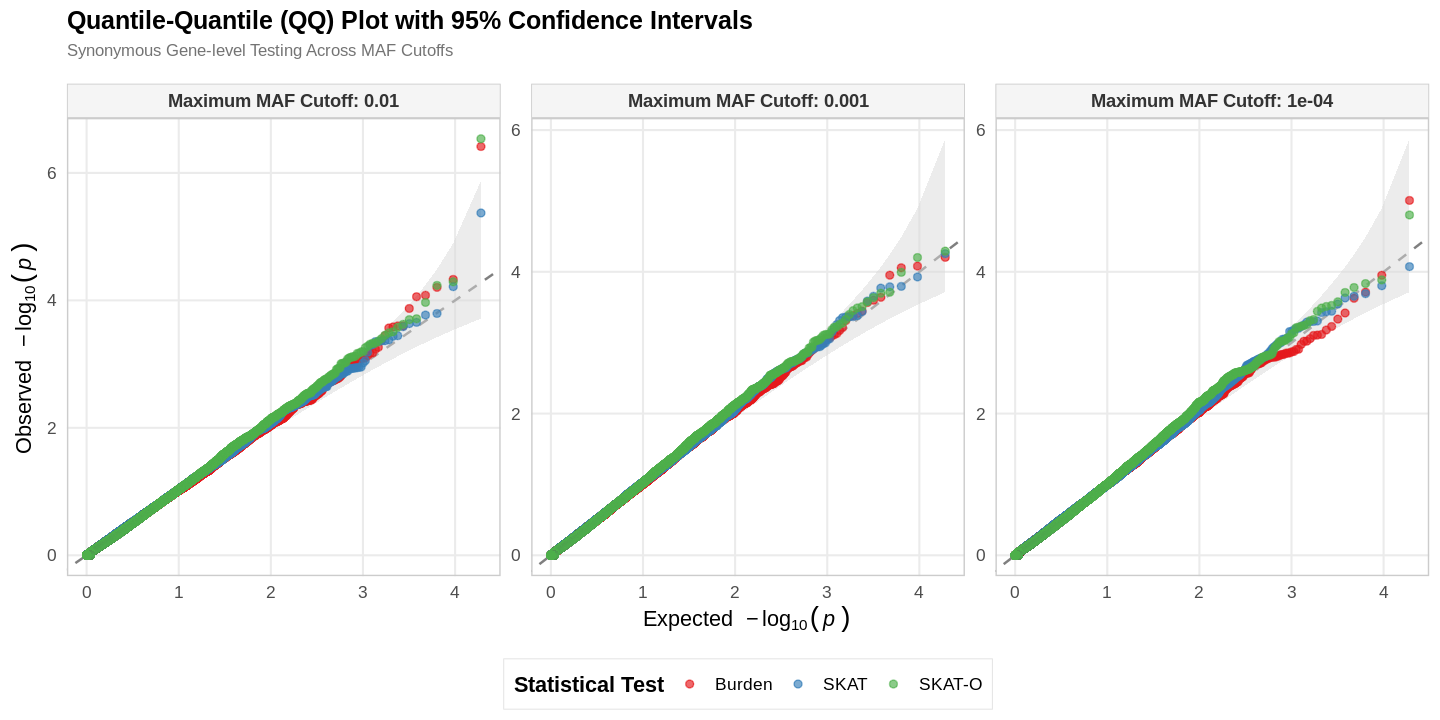

In [37]:
%%R -w 12 -h 6 --units in -r 120
library(data.table)
library(dplyr)
library(tidyr)
library(ggplot2)

# 1. Load Data Safely
setwd("/content")
dt <- fread(cmd = "zcat pilot-traits_uk-biobank_gene_uk-biobank.palmer.pilot.AFib.JULY23Freeze.ALL.EUR.28671.373704.SAIGE.gene.20240110.txt.gz")

# 2. Advanced Data Pipeline with Ordered Factors and Confidence Intervals
plot_data <- dt %>%
  filter(Group != "Cauchy") %>%
  pivot_longer(
    cols = c(Pvalue, Pvalue_Burden, Pvalue_SKAT),
    names_to = "class",
    values_to = "Pvalue"
  ) %>%
  mutate(
    class = case_match(
      class,
      "Pvalue"        ~ "SKAT-O",
      "Pvalue_Burden" ~ "Burden",
      "Pvalue_SKAT"   ~ "SKAT"
    ),
    Group = case_match(
      Group,
      "damaging_missense_or_protein_altering" ~ "Damaging missense",
      "other_missense_or_protein_altering"    ~ "Other missense",
      "pLoF"                                  ~ "pLoF",
      "pLoF;damaging_missense_or_protein_altering" ~ "pLoF, damaging missense",
      "pLoF;damaging_missense_or_protein_altering;other_missense_or_protein_altering;synonymous" ~ "pLoF, damaging missense, other missense, synonymous",
      "synonymous"                            ~ "Synonymous"
    ),
    # Create the clean string label
    max_MAF_label = paste0("Maximum MAF Cutoff: ", max_MAF)
  ) %>%
  filter(Group == "Synonymous") %>%
  # --- FIX 1: Sort by numeric MAF descending to lock in your custom facet order ---
  arrange(desc(max_MAF)) %>%
  mutate(max_MAF_label = factor(max_MAF_label, levels = unique(max_MAF_label))) %>%
  # Process mathematical ranks and null distributions
  group_by(class, Group, max_MAF) %>%
  arrange(Pvalue, .by_group = TRUE) %>%
  mutate(
    rank = row_number(),
    n_total = n(),
    Pvalue_exp = rank / (n_total + 1),
    lower_ci = qbeta(0.025, rank, n_total - rank + 1),
    upper_ci = qbeta(0.975, rank, n_total - rank + 1)
  ) %>%
  ungroup()

p <- ggplot(plot_data, aes(x = -log10(Pvalue_exp), y = -log10(Pvalue))) +

  # Identity Line
  geom_abline(intercept = 0, slope = 1, color = "grey50", linetype = "dashed", linewidth = 0.7) +
  geom_ribbon(
    data = filter(plot_data, class == "SKAT-O"),
    aes(x = -log10(Pvalue_exp), ymin = -log10(upper_ci), ymax = -log10(lower_ci)),
    fill = "grey85",
    alpha = 0.5,
    inherit.aes = FALSE
  ) +

  geom_point(aes(color = class), size = 1.8, alpha = 0.65) +

  # Multi-panel grid layout
  facet_wrap(~max_MAF_label, scales = 'free') +
  scale_color_brewer(palette = "Set1") +

  # Fine-Tuning Presentation Theme
  theme_minimal(base_size = 13) +
  theme(
    panel.border       = element_rect(color = "grey80", fill = NA, linewidth = 0.8),
    panel.grid.minor   = element_blank(),
    strip.background   = element_rect(fill = "grey96", color = "grey80", linewidth = 0.5),
    strip.text         = element_text(face = "bold", color = "grey20", size = 11),
    legend.position    = "bottom",
    legend.title       = element_text(face = "bold"),
    legend.background  = element_rect(fill = "white", color = "grey90", linewidth = 0.3),
    plot.title         = element_text(face = "bold", size = 15, margin = margin(b = 6)),
    plot.subtitle      = element_text(color = "grey45", size = 10, margin = margin(b = 15))
  ) +
  labs(
    title    = "Quantile-Quantile (QQ) Plot with 95% Confidence Intervals",
    subtitle = "Synonymous Gene-level Testing Across MAF Cutoffs",
    x        = expression(Expected~-log[10](italic(p))),
    y        = expression(Observed~-log[10](italic(p))),
    color    = "Statistical Test"
  )
print(p)

Discuss these plots in your group. What do you notice?

<details>
  <summary>💡 Click to reveal the explanation!</summary>
  
  You should have noticed that there's lift off from $y=x$ for synonymous variation, suggesting that there could well be common variant associations nearby that you're tagging. It might be a good idea to look and see if there are common variant associations close to those lead gene-phenotype associations.
</details>

---
## 🎉 End of SAIGE-Gene Practical
Great job! You have successfully installed SAIGE, run a null mixed model to control for population structure, performed rare variant group testing, and visualized the summary statistics of a real biobank-scale GWAS.